# Massachusetts Roads Dataset

here we are going to mask the road on the images.

In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# using kaggle hub for downloading

import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/massachusetts-roads-dataset")

print("Path to dataset files:", path)


#for exiting dataset
# path = "./dataset"

Using Colab cache for faster access to the 'massachusetts-roads-dataset' dataset.
Path to dataset files: /kaggle/input/massachusetts-roads-dataset


In [3]:
dirc = path
doc_file = pd.read_csv(dirc+"/metadata.csv")
doc_file

,image_id,split,image_souce_url,label_source_url,tiff_image_path,tif_label_path,png_image_path,png_label_path
0,10078660_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078660_15.tiff,tiff/train_labels/10078660_15.tif,png/train/10078660_15.png,png/train_labels/10078660_15.png
1,10078675_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078675_15.tiff,tiff/train_labels/10078675_15.tif,png/train/10078675_15.png,png/train_labels/10078675_15.png
2,10078690_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078690_15.tiff,tiff/train_labels/10078690_15.tif,png/train/10078690_15.png,png/train_labels/10078690_15.png
3,10078705_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078705_15.tiff,tiff/train_labels/10078705_15.tif,png/train/10078705_15.png,png/train_labels/10078705_15.png
4,10078720_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078720_15.tiff,tiff/train_labels/10078720_15.tif,png/train/10078720_15.png,png/train_labels/10078720_15.png
...,...,...,...,...,...,...,...,...
1166,25079170_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/25079170_15.tiff,tiff/test_labels/25079170_15.tif,png/test/25079170_15.png,png/test_labels/25079170_15.png
1167,26278720_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26278720_15.tiff,tiff/test_labels/26278720_15.tif,png/test/26278720_15.png,png/test_labels/26278720_15.png
1168,26428735_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26428735_15.tiff,tiff/test_labels/26428735_15.tif,png/test/26428735_15.png,png/test_labels/26428735_15.png
1169,26578720_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26578720_15.tiff,tiff/test_labels/26578720_15.tif,png/test/26578720_15.png,png/test_labels/26578720_15.png


In [13]:
train_files = doc_file[doc_file["split"] == "train"]["tiff_image_path"]
train_label_files = doc_file[doc_file["split"] == "train"]["tif_label_path"]
train_files,train_label_files

(0       tiff/train/10078660_15.tiff
 1       tiff/train/10078675_15.tiff
 2       tiff/train/10078690_15.tiff
 3       tiff/train/10078705_15.tiff
 4       tiff/train/10078720_15.tiff
                    ...             
 1103    tiff/train/27028705_15.tiff
 1104    tiff/train/27028720_15.tiff
 1105    tiff/train/27178705_15.tiff
 1106    tiff/train/99238660_15.tiff
 1107    tiff/train/99238675_15.tiff
 Name: tiff_image_path, Length: 1108, dtype: object,
 0       tiff/train_labels/10078660_15.tif
 1       tiff/train_labels/10078675_15.tif
 2       tiff/train_labels/10078690_15.tif
 3       tiff/train_labels/10078705_15.tif
 4       tiff/train_labels/10078720_15.tif
                       ...                
 1103    tiff/train_labels/27028705_15.tif
 1104    tiff/train_labels/27028720_15.tif
 1105    tiff/train_labels/27178705_15.tif
 1106    tiff/train_labels/99238660_15.tif
 1107    tiff/train_labels/99238675_15.tif
 Name: tif_label_path, Length: 1108, dtype: object)

In [14]:
import os

train_files = [os.path.join(dirc,f) for f in train_files]
train_label_files = [os.path.join(dirc,f) for f in train_label_files]

In [15]:
train_files = [Image.open(f).resize((256,256)) for f in train_files]
train_label_files = [Image.open(f).resize((256,256)) for f in train_label_files]

In [16]:
# for f in train_files:
#     if f.size != (1500,1500):
#         print(f.size)

# for f in train_label_files:
#     if f.size != (1500,1500):
#         print(f.size)

All the training files are of same size (1500,1500) (converted to (256,256))

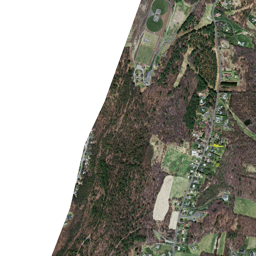

In [17]:
train_files[4]

The image is corrupted and partial infomation is available.
Firstly to avoid these to trouble the model, I will mask the label such that the blank implies no roads.
I also tried with the defects.

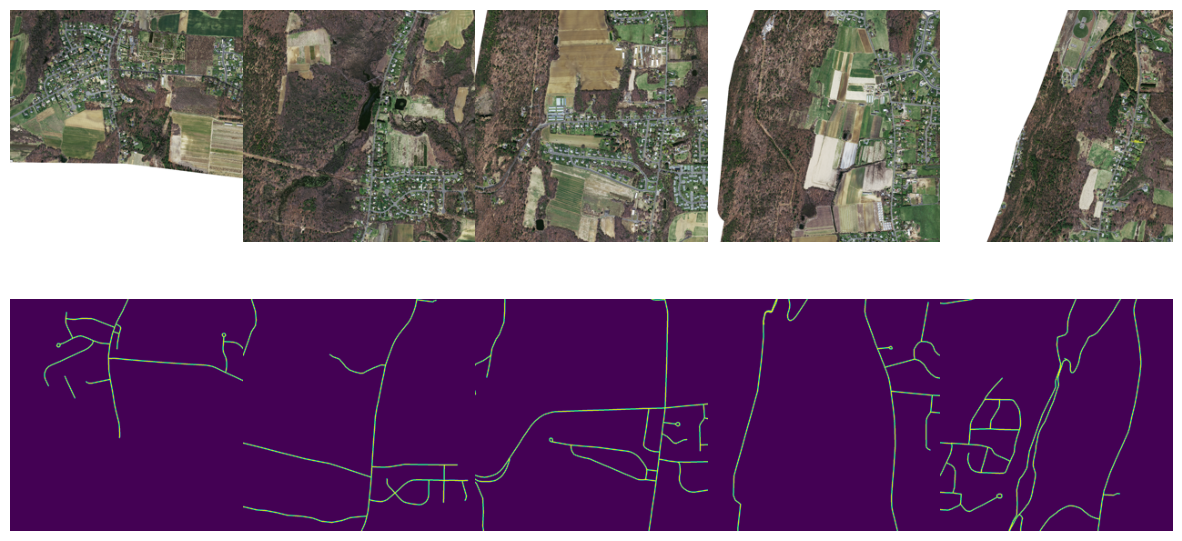

In [18]:

plt.figure(figsize=(15,15))
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.axis("off")
    plt.imshow(train_files[i])
    plt.subplot(1,5,i+1)
    plt.axis("off")
    plt.imshow(train_label_files[i])

The annotation are human made and thus some road look way obivious and some hard to see. Some lines also seem to be road but there aren't labeled implying that all the path are not road. Thus we have to in particular select the official marked roads only which may confuuse the model.

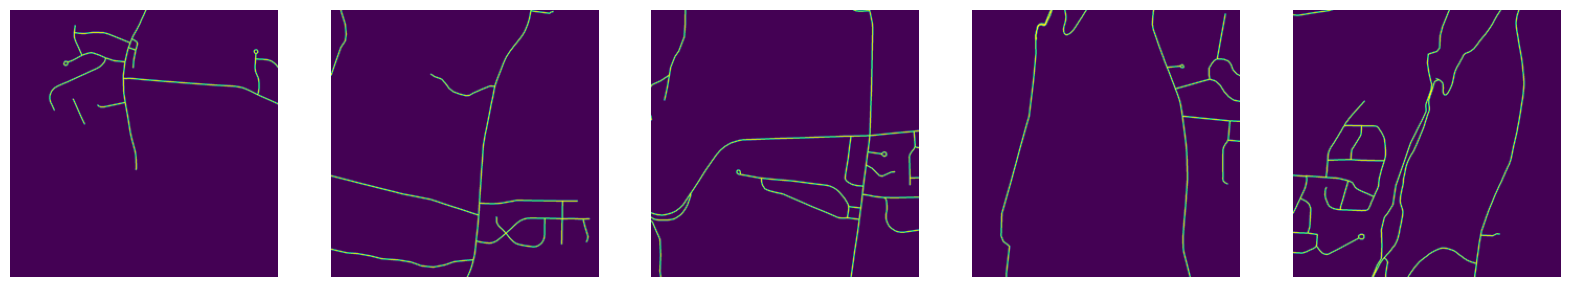

In [19]:

plt.figure(figsize=(20,20))
plt.tight_layout()
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.axis("off")
    plt.imshow(train_label_files[i])

moreover the road are very few pixels thus making it difficult for the model to learn.

In [20]:
np.asarray(train_files[0])[:2,:2]

array([[[99, 83, 73],
        [62, 82, 50]],

       [[99, 83, 73],
        [88, 85, 65]]], dtype=uint8)

In [22]:
np.asarray(train_files[0])[-2:,-2:]

array([[[255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255]]], dtype=uint8)

In [21]:
np.asarray(train_label_files[0]).sum()

np.uint64(215124)

the image is in rgb format. and the unknown data is white

In [25]:
from torch.utils.data import DataLoader,Dataset

class RoadDataset(Dataset):
    def __init__(self, inputs, labels, transform, label_transform):
        self.x = [transform(i) for i in inputs]
        self.y = [label_transform(inputs[i],labels[i]) for i in range(len(labels))]

    def __len__(self):
        return len(self.y)

    def __getitem__(self,idx):
        return self.x[idx], self.y[idx]



In [38]:
def input_transform(x:Image.Image,mean,std):
    x = np.asarray(x,dtype=np.float32)/255.0
    x  = (x-mean)/std
    x = torch.tensor(x).transpose(-1,-2).transpose(-2,-3)
    return x

def label_transform(x:torch.Tensor, y:Image.Image):
    y = np.asarray(y,dtype=np.float32)/255.0
    y = torch.tensor(y)

    x_ = torch.Tensor(np.asarray(x)).mean(dim=-1)
    x_ = torch.where(x_ == 255, 0, 1) # white pixel part are removeded
    return y*x_


In [39]:
x = np.asarray([np.asarray(i,dtype=np.float32)/255.0 for i  in train_files])
mean = np.mean(x)
std = np.std(x)
in_transform = lambda x : input_transform(x,mean,std)
train_dataset = RoadDataset(train_files,train_label_files,in_transform,label_transform)
train_size = len(train_dataset)

In [40]:
valid_files = doc_file[doc_file["split"] == "val"]["tiff_image_path"]
valid_label_files = doc_file[doc_file["split"] == "val"]["tif_label_path"]

valid_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in valid_files]
valid_label_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in valid_label_files]

valid_dataset = RoadDataset(valid_files,valid_label_files,in_transform,label_transform)
valid_size = len(valid_dataset)

In [41]:
test_files = doc_file[doc_file["split"] == "test"]["tiff_image_path"]
test_label_files = doc_file[doc_file["split"] == "test"]["tif_label_path"]

test_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in test_files]
test_label_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in test_label_files]

test_dataset = RoadDataset(test_files,test_label_files,in_transform,label_transform)
test_size = len(test_dataset)

# Making a U-net
here is a implementation for unet where I have used convolution of kernel size 5 and at output I have used a max pool.

Here I have used this architecture to deal with the shape of the output tensor match the original image.

Rather than croping the image, I have taken a the global average pool to get a better picture.

In [42]:
class RoadPredictor(nn.Module):
    def __init__(self,device):
        super().__init__()

        self.convs = nn.ModuleList([nn.Conv2d(3,8,5).to(device),
                                    nn.Conv2d(8,8,5).to(device),
                                    nn.Conv2d(8,8,5).to(device),
                                    nn.Conv2d(16,8,5).to(device),
                                    nn.Conv2d(16,8,5).to(device)])
        self.maxpool = nn.ModuleList([nn.MaxPool2d(2).to(device) for i in range(2)])
        self.upconvs = nn.ModuleList([nn.ConvTranspose2d(8,8,2,stride=2).to(device) for i in range(2)])
        self.upconvs.append(nn.ConvTranspose2d(8,1,4,stride=2).to(device))
        self.gaps = nn.ModuleList([
            nn.AdaptiveAvgPool2d((114,114)).to(device),
            nn.AdaptiveAvgPool2d((220,220)).to(device),
            nn.AdaptiveMaxPool2d((256,256)).to(device)])

    def forward(self,x):
        x1 = self.convs[0](x)
        x2 = self.maxpool[0](x1)
        x3 = self.convs[1](x2)
        x4 = self.maxpool[1](x3)
        x5 = self.convs[2](x4)
        x6 = self.upconvs[0](x5)
        x6 = torch.concat([x6,self.gaps[0](x3)], dim=1)
        x7 = self.convs[3](x6)
        x8 = self.upconvs[1](x7)
        x8 = torch.concat([x8,self.gaps[1](x1)], dim=1)
        x8 = self.convs[4](x8)
        x9 = self.upconvs[2](x8)
        x9 = self.gaps[2](x9)
        return x9.reshape(-1,256*256)

In [43]:
# I have used different loss function to see how the model behave to it.

class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.reshape(-1)
        target = target.reshape(-1)
        intersection = torch.dot(pred,target)
        dice = (2.*intersection)/(pred.sum() + target.sum())
        return 1 - dice

class BCEAndDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss1 = nn.BCEWithLogitsLoss()
        self.loss2 = DiceLoss()

    def forward(self, pred, target):
        return .005*self.loss1(pred,target) + self.loss2(pred,target)

class DoubleDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss1 = DiceLoss()
        self.loss2 = DiceLoss()
    def forward(self, pred, target):

        # the factor is added to deal with the class weight
        return self.loss1(pred,target) + 1e-3*self.loss2(1 - pred,1 - target)

class FocalLoss(nn.Module):
    def __init__(self, weight=1., gamma = 2.):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.reshape(-1)
        target = target.reshape(-1)
        l = target*((1 - pred)**self.gamma)*torch.log(pred) + self.weight*(1 - target)*(pred**self.gamma)*torch.log(1 - pred)
        return -l.sum()

In [44]:
# Focal loss

In [45]:
def train_model(model,loss_fn,opt,max_epochs,train_data,valid_data,device):
    model = model.to(device)
    loss_fn = loss_fn.to(device)
    accuracy = []
    losses = []
    model.train()
    for i in range(max_epochs):
        s = 0
        for (x,y) in train_data:
            y = y.to(device).reshape(-1,256*256)
            x = x.to(device)
            pred = model(x)
            loss = loss_fn(pred,y)
            losses.append(loss.cpu().item())
            loss.backward()
            s+=loss.item()
            opt.step()
            opt.zero_grad()
        with torch.no_grad():
            total = 0
            for (x,y) in valid_data:
                y = y.to(device).reshape(-1,256*256)
                x = x.to(device)
                pred = model(x)
                pred = torch.sigmoid(pred)
                pred = torch.where(pred >= 0.5, 1, 0)
                total += (y == pred).reshape(-1).sum().cpu().item()
            accuracy.append(total/valid_size/256/256)
            if (i%10 == 0):
                print(f"Epoch {i+1}: valid acc :{accuracy[-1]} training_loss:{losses[-1]}")

    return model, accuracy , losses

In [46]:
def diceloss(target, pred):
    pred = torch.sigmoid(pred)
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    intersection = torch.dot(pred,target)
    score = (2.*intersection)/(pred.sum() + target.sum())
    return score

def iou(target, pred):
    pred = torch.sigmoid(pred)
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    intersection = torch.dot(pred,target)
    score = intersection/(pred.sum() + target.sum()-intersection)
    return score

def eval_model(model,test_data):
  model.eval()
  tp= tn = fp = fn = 0
  dice_loss = 0
  iou_loss = 0
  for (x,y) in test_data:
    x = x.to(device)
    y = y.to(device).reshape(-1,256*256)
    pred = model(x)
    y_ = torch.where(y >0.5, 1, 0)
    pred_ = torch.where(pred > 0.5, 1, 0)
    matches = (y_ == pred_)
    tp += (matches*(y_==1)).sum()
    tn += (matches*(y_==0)).sum()
    fp += ((~matches)*(y_==1)).sum()
    fn += ((~matches)*(y_==0)).sum()
    dice_loss += diceloss(y,pred)
    iou_loss += iou(y,pred)
  print(f"""
  Accuracy: {(tp+tn)/(tp+tn+fp+fn)}
  Recall: {(tp)/(tp+fn)}
  Presicion: {(tp)/(tp+fp)}
  IOU: {iou_loss}
  diceloss: {dice_loss}
  """)

In [47]:
train_data = DataLoader(train_dataset,batch_size=256)
valid_data = DataLoader(valid_dataset,batch_size=4096)
test_data = DataLoader(test_dataset,batch_size=4096)

Epoch 1: valid acc :0.18243299211774552 training_loss:0.962126612663269
Epoch 11: valid acc :0.011021205357142858 training_loss:0.9501584768295288
Epoch 21: valid acc :0.4956021990094866 training_loss:0.8941318988800049
Epoch 31: valid acc :0.2094573974609375 training_loss:0.9469456672668457
Epoch 41: valid acc :0.1321836199079241 training_loss:0.9496762156486511
Epoch 51: valid acc :0.12606593540736608 training_loss:0.9491340517997742
Epoch 61: valid acc :0.1546478271484375 training_loss:0.9478502869606018
Epoch 71: valid acc :0.5848345075334821 training_loss:0.890537679195404
Epoch 81: valid acc :0.5746786934988839 training_loss:0.8829731345176697
Epoch 91: valid acc :0.6326032366071429 training_loss:0.8796207904815674
Epoch 101: valid acc :0.6467808314732143 training_loss:0.8755886554718018
Epoch 111: valid acc :0.6517388480050224 training_loss:0.8732335567474365
Epoch 121: valid acc :0.661881583077567 training_loss:0.870643138885498
Epoch 131: valid acc :0.6709583827427456 training

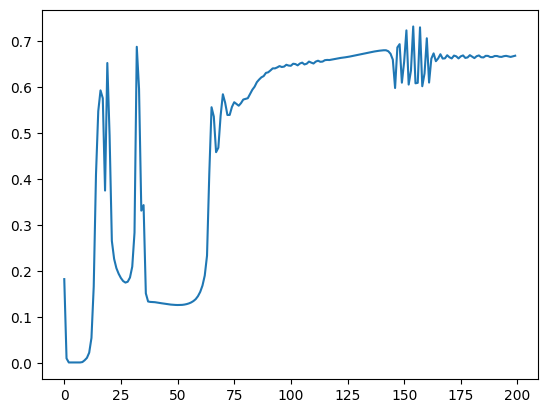

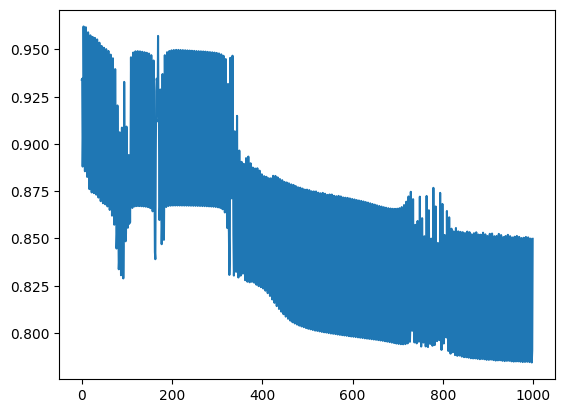

In [51]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model = RoadPredictor(device)
loss_fn = DiceLoss()
opt = torch.optim.AdamW(model.parameters(),lr = 1e-3)
model_diceloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)

Epoch 1: valid acc :0.03750828334263393 training_loss:0.7409472465515137
Epoch 11: valid acc :0.850480215890067 training_loss:0.1342361569404602
Epoch 21: valid acc :0.8505074637276786 training_loss:0.09935124963521957
Epoch 31: valid acc :0.8538000924246651 training_loss:0.09546241164207458
Epoch 41: valid acc :0.8537957327706474 training_loss:0.09398050606250763
Epoch 51: valid acc :0.8537870134626117 training_loss:0.09325048327445984
Epoch 61: valid acc :0.8537859235491071 training_loss:0.09274175763130188
Epoch 71: valid acc :0.8537946428571429 training_loss:0.09233849495649338
Epoch 81: valid acc :0.8538000924246651 training_loss:0.09197728335857391
Epoch 91: valid acc :0.8538088117327008 training_loss:0.09162583202123642
Epoch 101: valid acc :0.8538088117327008 training_loss:0.09127059578895569
Epoch 111: valid acc :0.8538088117327008 training_loss:0.09091520309448242
Epoch 121: valid acc :0.8538077218191964 training_loss:0.09057518094778061
Epoch 131: valid acc :0.85380118233816

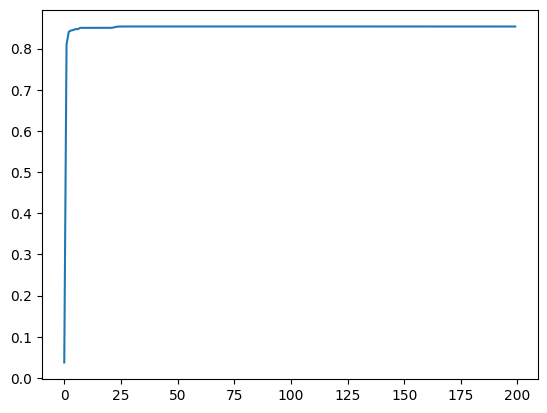

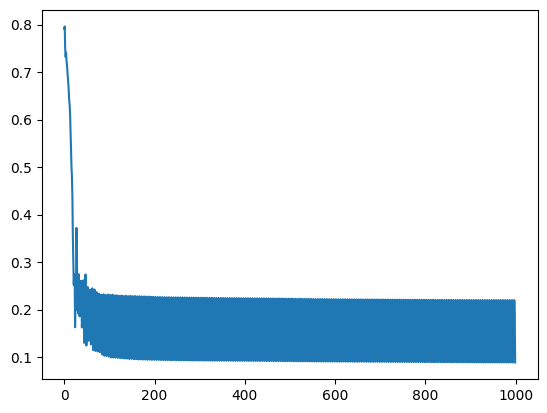

In [52]:
model = RoadPredictor(device)
loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.AdamW(model.parameters(),lr = 1e-3)
model_bce,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)
plt.show()

Epoch 1: valid acc :0.00102996826171875 training_loss:0.9660066962242126
Epoch 11: valid acc :0.5127770560128349 training_loss:0.8988815546035767
Epoch 21: valid acc :0.6977811540876117 training_loss:0.8743729591369629
Epoch 31: valid acc :0.6953506469726562 training_loss:0.8659075498580933
Epoch 41: valid acc :0.6777354649135044 training_loss:0.8625496029853821
Epoch 51: valid acc :0.6755785260881696 training_loss:0.8575510382652283
Epoch 61: valid acc :0.6792711530412946 training_loss:0.8536295294761658
Epoch 71: valid acc :0.6826182774135044 training_loss:0.8525944352149963
Epoch 81: valid acc :0.6761343819754464 training_loss:0.8522753715515137
Epoch 91: valid acc :0.6860002790178571 training_loss:0.8477174043655396
Epoch 101: valid acc :0.6953811645507812 training_loss:0.8466721773147583
Epoch 111: valid acc :0.6638902936662946 training_loss:0.8504996299743652
Epoch 121: valid acc :0.7039685930524554 training_loss:0.8420735597610474
Epoch 131: valid acc :0.6606532505580357 trainin

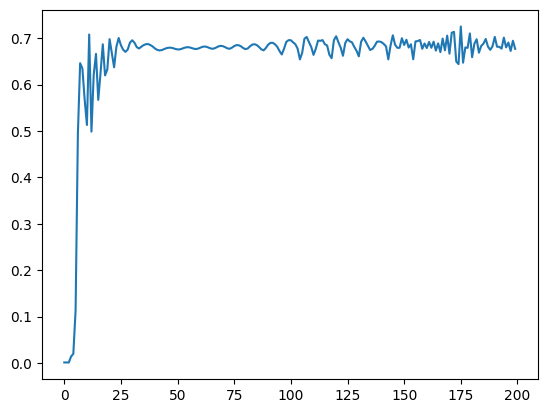

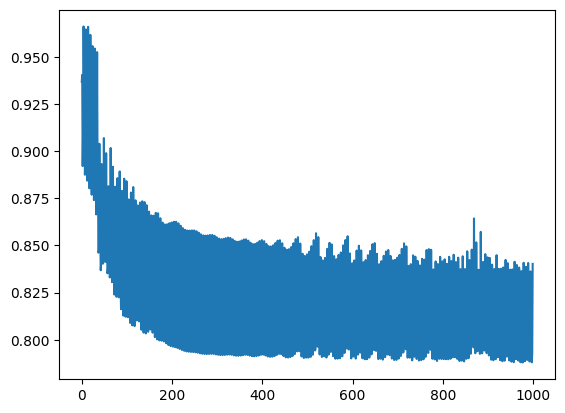

In [60]:
model = RoadPredictor(device)
loss_fn = BCEAndDiceLoss()
opt = torch.optim.AdamW(model.parameters(),lr = 2e-3)
model_bceanddiceloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)

Epoch 1: valid acc :0.0009787423270089285 training_loss:0.9622150659561157
Epoch 11: valid acc :0.008013044084821428 training_loss:0.9518794417381287
Epoch 21: valid acc :0.41786302839006695 training_loss:0.9538838863372803
Epoch 31: valid acc :0.4135807582310268 training_loss:0.9521151185035706
Epoch 41: valid acc :0.7184241158621651 training_loss:0.8923950791358948
Epoch 51: valid acc :0.518632071358817 training_loss:0.8925391435623169
Epoch 61: valid acc :0.591660635811942 training_loss:0.8746201395988464
Epoch 71: valid acc :0.6374239240373883 training_loss:0.86908358335495
Epoch 81: valid acc :0.6507829938616071 training_loss:0.864321231842041
Epoch 91: valid acc :0.6571622576032367 training_loss:0.8609313368797302
Epoch 101: valid acc :0.6592309134347099 training_loss:0.8588516116142273
Epoch 111: valid acc :0.6604112897600446 training_loss:0.8562642931938171
Epoch 121: valid acc :0.6610096522739956 training_loss:0.8540485501289368
Epoch 131: valid acc :0.6625104631696429 trainin

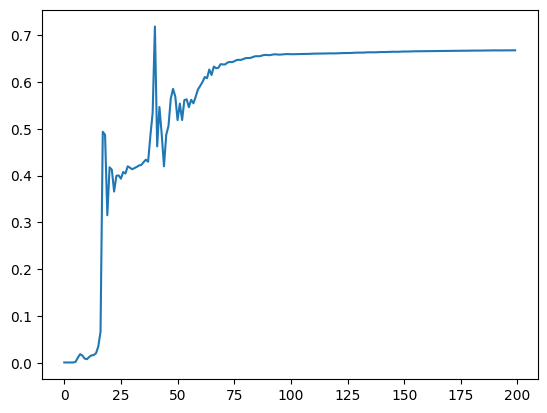

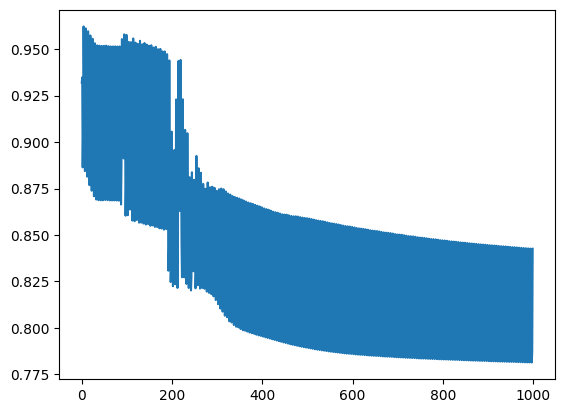

In [68]:
model = RoadPredictor(device)
loss_fn = DoubleDiceLoss()
opt = torch.optim.AdamW(model.parameters(),lr = 1e-3)
model_doublediceloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)

Epoch 1: valid acc :0.00115203857421875 training_loss:8670.5029296875
Epoch 11: valid acc :0.0009787423270089285 training_loss:8056.046875
Epoch 21: valid acc :0.0011237008231026785 training_loss:7955.0712890625
Epoch 31: valid acc :0.0014866420200892857 training_loss:7898.3662109375
Epoch 41: valid acc :0.0034081595284598215 training_loss:7550.2275390625
Epoch 51: valid acc :0.010019574846540178 training_loss:7363.20751953125
Epoch 61: valid acc :0.008602687290736608 training_loss:7446.724609375
Epoch 71: valid acc :0.013208661760602678 training_loss:7364.7197265625
Epoch 81: valid acc :0.023965018136160716 training_loss:7258.7958984375
Epoch 91: valid acc :0.029935564313616072 training_loss:7182.720703125
Epoch 101: valid acc :0.03219822474888393 training_loss:7124.3271484375
Epoch 111: valid acc :0.03503199986049107 training_loss:7097.244140625
Epoch 121: valid acc :0.03614153180803571 training_loss:7083.51611328125
Epoch 131: valid acc :0.03150177001953125 training_loss:7123.764648

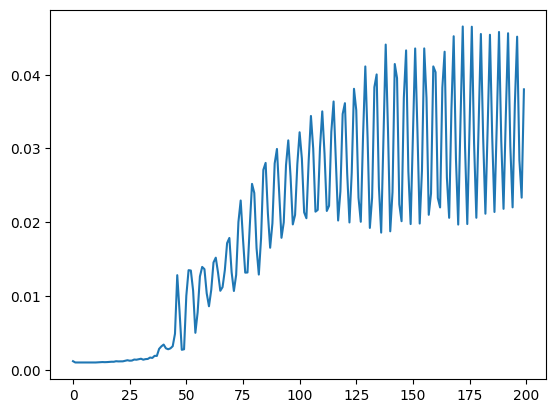

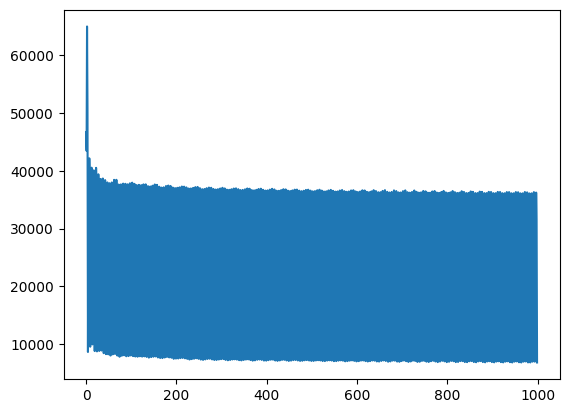

In [55]:
model = RoadPredictor(device)
loss_fn = FocalLoss(5e-3,3)
opt = torch.optim.AdamW(model.parameters(),lr = 1e-3)
model_focalloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)


  Accuracy: 0.8433707356452942
  Recall: 0.13779428601264954
  Presicion: 0.41288602352142334
  IOU: 0.11335890740156174
  diceloss: 0.20363406836986542
  


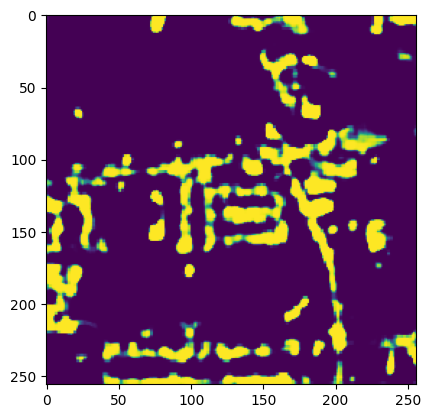

In [56]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_diceloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = (pred[0])
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_diceloss,test_data)


  Accuracy: 0.9505898356437683
  Recall: 0.0
  Presicion: 0.0
  IOU: 0.044253870844841
  diceloss: 0.08475691825151443
  


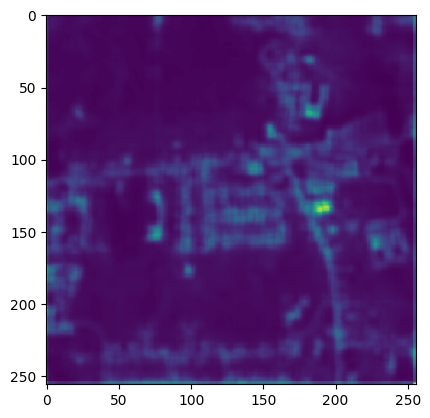

In [57]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_bce(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_bce,test_data)


  Accuracy: 0.8442317247390747
  Recall: 0.14030395448207855
  Presicion: 0.41993987560272217
  IOU: 0.11529506742954254
  diceloss: 0.20675258338451385
  


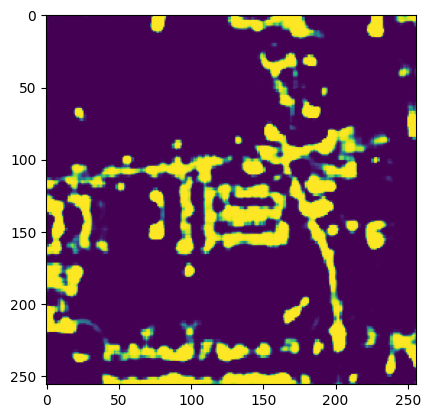

In [62]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_bceanddiceloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_bceanddiceloss, test_data)


  Accuracy: 0.8387837409973145
  Recall: 0.13880589604377747
  Presicion: 0.43492376804351807
  IOU: 0.1154649406671524
  diceloss: 0.2070256918668747
  


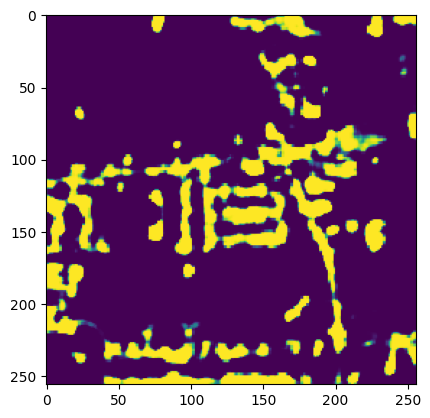

In [69]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_doublediceloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_doublediceloss, test_data)


  Accuracy: 0.5756060481071472
  Recall: 0.0910455510020256
  Presicion: 0.8449857234954834
  IOU: 0.052731409668922424
  diceloss: 0.10018017888069153
  


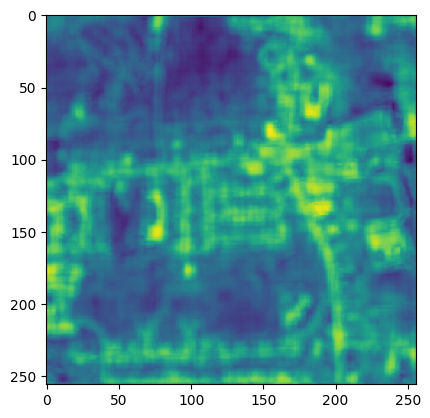

In [64]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_focalloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_focalloss,test_data)

In [67]:
torch.save(model_focalloss.state_dict(), f"./model_focal.trhmodel")
torch.save(model_doublediceloss.state_dict(), f"./model_doublediceloss.trhmodel")
torch.save(model_bceanddiceloss.state_dict(), f"./model_bceanddiceloss.trhmodel")
torch.save(model_bce.state_dict(), f"./model_bce.trhmodel")
torch.save(model_diceloss.state_dict(), f"./model_diceloss.trhmodel")

here we can see the predicton are way blurry and though they give region highlighted. That implies that the global averaging and maxpooling are not good as they compress the detials. Moreover we need more convolution layers such that is can give a better prediction.

so in the next notebook, I have removed the global averaging and maxpools and used more convolution.